## Financial statement analysis

# Purpose
Automatically analyse a company's financial statements across multiple years and produce:
1. A ratio/KPI dashboard (Revenue Growth, Gross Margin, EBIT Margin, Net Profit Margin, Current Ratio, Quick Ratio, Debt to Equity, Interest Coverage, ROA, ROE, Working Capital).
2. Trend charts (Revenue, EBITDA, Operating Cash Flow, Net Income)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
input_df = pd.read_csv("input_template.csv", index_col=0).T
input_df

line_item,revenue,cogs,ebit,da,interest_expense,net_income,current_assets,inventory,current_liabilities,total_assets,total_equity,total_debt,operating_cash_flow
2023,1000000,600000,180000,20000,15000,116250,350000,90000,180000,900000,500000,250000,140000
2024,1200000,700000,240000,25000,14000,169500,420000,100000,210000,1050000,620000,240000,195000
2025,1450000,830000,320000,30000,12000,231000,500000,115000,240000,1220000,790000,220000,255000


In [3]:
input_df = pd.read_csv("input_template.csv", index_col=0)
input_df

,2023,2024,2025
line_item,,,
revenue,1000000,1200000,1450000
cogs,600000,700000,830000
ebit,180000,240000,320000
da,20000,25000,30000
interest_expense,15000,14000,12000
net_income,116250,169500,231000
current_assets,350000,420000,500000
inventory,90000,100000,115000
current_liabilities,180000,210000,240000


In [4]:
data = {int(year): input_df[year].to_dict() for year in input_df.columns}
years = sorted(data.keys())
data

{2023: {'revenue': 1000000,
  'cogs': 600000,
  'ebit': 180000,
  'da': 20000,
  'interest_expense': 15000,
  'net_income': 116250,
  'current_assets': 350000,
  'inventory': 90000,
  'current_liabilities': 180000,
  'total_assets': 900000,
  'total_equity': 500000,
  'total_debt': 250000,
  'operating_cash_flow': 140000},
 2024: {'revenue': 1200000,
  'cogs': 700000,
  'ebit': 240000,
  'da': 25000,
  'interest_expense': 14000,
  'net_income': 169500,
  'current_assets': 420000,
  'inventory': 100000,
  'current_liabilities': 210000,
  'total_assets': 1050000,
  'total_equity': 620000,
  'total_debt': 240000,
  'operating_cash_flow': 195000},
 2025: {'revenue': 1450000,
  'cogs': 830000,
  'ebit': 320000,
  'da': 30000,
  'interest_expense': 12000,
  'net_income': 231000,
  'current_assets': 500000,
  'inventory': 115000,
  'current_liabilities': 240000,
  'total_assets': 1220000,
  'total_equity': 790000,
  'total_debt': 220000,
  'operating_cash_flow': 255000}}

In [5]:
rows = {}
prev_revenue = None

for year in years:
    d = data[year]
    gross_profit = d["revenue"] - d["cogs"]
    ebitda = d["ebit"] + d["da"]
    revenue_growth = (d["revenue"] - prev_revenue) / prev_revenue if prev_revenue else None
    prev_revenue = d["revenue"]

    rows[year] = { "Revenue": d["revenue"], "EBITDA": ebitda, "Net Income": d["net_income"], "Operating Cash Flow": d["operating_cash_flow"],
        "Revenue Growth": revenue_growth, "Gross Margin": gross_profit / d["revenue"], "EBIT Margin": d["ebit"] / d["revenue"],
        "Net Profit Margin": d["net_income"] / d["revenue"],  "Current Ratio": d["current_assets"] / d["current_liabilities"],
        "Quick Ratio": (d["current_assets"] - d["inventory"]) / d["current_liabilities"],  "Debt to Equity": d["total_debt"] / d["total_equity"],
        "Interest Coverage": d["ebit"] / d["interest_expense"], "ROA": d["net_income"] / d["total_assets"], "ROE": d["net_income"] / d["total_equity"],
        "Working Capital": d["current_assets"] - d["current_liabilities"],}
rows

{2023: {'Revenue': 1000000,
  'EBITDA': 200000,
  'Net Income': 116250,
  'Operating Cash Flow': 140000,
  'Revenue Growth': None,
  'Gross Margin': 0.4,
  'EBIT Margin': 0.18,
  'Net Profit Margin': 0.11625,
  'Current Ratio': 1.9444444444444444,
  'Quick Ratio': 1.4444444444444444,
  'Debt to Equity': 0.5,
  'Interest Coverage': 12.0,
  'ROA': 0.12916666666666668,
  'ROE': 0.2325,
  'Working Capital': 170000},
 2024: {'Revenue': 1200000,
  'EBITDA': 265000,
  'Net Income': 169500,
  'Operating Cash Flow': 195000,
  'Revenue Growth': 0.2,
  'Gross Margin': 0.4166666666666667,
  'EBIT Margin': 0.2,
  'Net Profit Margin': 0.14125,
  'Current Ratio': 2.0,
  'Quick Ratio': 1.5238095238095237,
  'Debt to Equity': 0.3870967741935484,
  'Interest Coverage': 17.142857142857142,
  'ROA': 0.16142857142857142,
  'ROE': 0.27338709677419354,
  'Working Capital': 210000},
 2025: {'Revenue': 1450000,
  'EBITDA': 350000,
  'Net Income': 231000,
  'Operating Cash Flow': 255000,
  'Revenue Growth': 0.2

In [6]:
ratios = pd.DataFrame(rows).T
# T is for transpose
ratios.index.name = "Year"
ratios

,Revenue,EBITDA,Net Income,Operating Cash Flow,Revenue Growth,Gross Margin,EBIT Margin,Net Profit Margin,Current Ratio,Quick Ratio,Debt to Equity,Interest Coverage,ROA,ROE,Working Capital
Year,,,,,,,,,,,,,,,
2023,1000000.0,200000.0,116250.0,140000.0,NaN,0.400000,0.18000,0.11625,1.944444,1.444444,0.500000,12.000000,0.129167,0.232500,170000.0
2024,1200000.0,265000.0,169500.0,195000.0,0.200000,0.416667,0.20000,0.14125,2.000000,1.523810,0.387097,17.142857,0.161429,0.273387,210000.0
2025,1450000.0,350000.0,231000.0,255000.0,0.208333,0.427586,0.22069,0.15931,2.083333,1.604167,0.278481,26.666667,0.189344,0.292405,260000.0


In [7]:
print("FINANCIAL STATEMENT ANALYSIS DASHBOARD")
print("=" * 40)
for col in ratios.columns:
    print(f"\n{col}:")
    for year, val in ratios[col].items():
        if val is None or pd.isna(val):
            print(f"  {year}: n/a")
        elif col in ["Revenue Growth", "Gross Margin", "EBIT Margin", "Net Profit Margin", "ROA", "ROE"]:
            print(f"  {year}: {val*100:.1f}%")
        elif col in ["Current Ratio", "Quick Ratio", "Debt to Equity", "Interest Coverage"]:
            print(f"  {year}: {val:.2f}x")
        else:
            print(f"  {year}: {val:,.0f}")

FINANCIAL STATEMENT ANALYSIS DASHBOARD

Revenue:
  2023: 1,000,000
  2024: 1,200,000
  2025: 1,450,000

EBITDA:
  2023: 200,000
  2024: 265,000
  2025: 350,000

Net Income:
  2023: 116,250
  2024: 169,500
  2025: 231,000

Operating Cash Flow:
  2023: 140,000
  2024: 195,000
  2025: 255,000

Revenue Growth:
  2023: n/a
  2024: 20.0%
  2025: 20.8%

Gross Margin:
  2023: 40.0%
  2024: 41.7%
  2025: 42.8%

EBIT Margin:
  2023: 18.0%
  2024: 20.0%
  2025: 22.1%

Net Profit Margin:
  2023: 11.6%
  2024: 14.1%
  2025: 15.9%

Current Ratio:
  2023: 1.94x
  2024: 2.00x
  2025: 2.08x

Quick Ratio:
  2023: 1.44x
  2024: 1.52x
  2025: 1.60x

Debt to Equity:
  2023: 0.50x
  2024: 0.39x
  2025: 0.28x

Interest Coverage:
  2023: 12.00x
  2024: 17.14x
  2025: 26.67x

ROA:
  2023: 12.9%
  2024: 16.1%
  2025: 18.9%

ROE:
  2023: 23.2%
  2024: 27.3%
  2025: 29.2%

Working Capital:
  2023: 170,000
  2024: 210,000
  2025: 260,000


In [8]:
#to save the ratio table
ratios.to_csv("dashboard_ratios.csv")
with open("dashboard_summary.txt", "w") as f:
    f.write(ratios.to_string())

In [1]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Financial Performance Trends", fontsize=14, fontweight="bold");

#plot revenue
axes[0, 0].plot(years, ratios["Revenue"], marker="o", linewidth=2, color="blue", label = "Revenue")
axes[0, 0].set_title("Revenue")
axes[0, 0].set_xticks(years)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()
axes[0,0].set_xlabel("Year")
axes[0, 0].set_ylabel("Amount (₦ Millions)")

#plot EBITDA
axes[0, 1].plot(years, ratios["EBITDA"], marker="o", linewidth=2, color="green", label = "EBITDA")
axes[0, 1].set_title("EBITDA")
axes[0, 1].set_xticks(years)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Amount (₦ Millions)")

# plot operating cash flow
axes[1, 0].plot(years, ratios["Operating Cash Flow"], marker="o", linewidth=2, color="red", label = "Operating cash flow")
axes[1, 0].set_title("Operating Cash Flow")
axes[1, 0].set_xticks(years)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Amount (₦ Millions)")

#plot net income
axes[1, 1].plot(years, ratios["Net Income"], marker="o", linewidth=2, color="purple", label = "Net income")
axes[1, 1].set_title("Net Income")
axes[1, 1].set_xticks(years)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Amount (₦ Millions)")

#to prevent the charts from displaying now
plt.ioff()
plt.close(fig)

NameError: name 'plt' is not defined

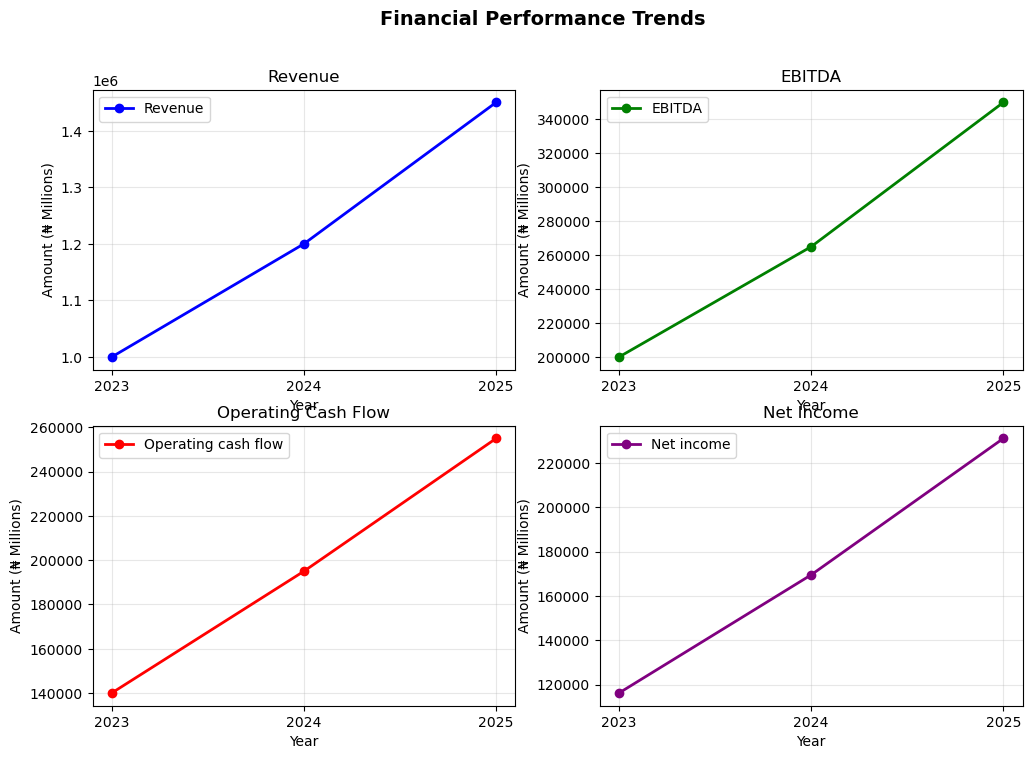

In [10]:
# Finalise and display all charts at once
plt.tight_layout()
plt.savefig("trend_charts.png", dpi=150)
fig

In [11]:
first_year = years[0]
last_year = years[-1]

revenue_change = (ratios["Revenue"][last_year] - ratios["Revenue"][first_year]) / ratios["Revenue"][first_year] * 100
gross_margin_first = ratios["Gross Margin"][first_year] * 100
gross_margin_last = ratios["Gross Margin"][last_year] * 100
debt_to_equity_first = ratios["Debt to Equity"][first_year]
debt_to_equity_last = ratios["Debt to Equity"][last_year]
ocf_last = ratios["Operating Cash Flow"][last_year]

insights = []
insights.append(f"Revenue {'increased' if revenue_change >= 0 else 'declined'} {abs(revenue_change):.0f}% from {first_year} to {last_year}")
insights.append(f"Gross Margin {'improved' if gross_margin_last >= gross_margin_first else 'declined'} from {gross_margin_first:.0f}% to {gross_margin_last:.0f}%")
insights.append(f"Debt to Equity {'declined' if debt_to_equity_last < debt_to_equity_first else 'increased'} from {debt_to_equity_first:.2f}x to {debt_to_equity_last:.2f}x")
insights.append(f"Operating Cash Flow is {'positive' if ocf_last > 0 else 'negative'} in {last_year}")

print("FINANCIAL HEALTH SUMMARY")
print("=" * 50)
for line in insights:
    print(f"✔ {line}")

# scoring logic for recommendation
score = sum([ revenue_change > 0, gross_margin_last >= gross_margin_first, debt_to_equity_last < debt_to_equity_first, ocf_last > 0,])

print("\nRecommendation:")
if score == 4:
    print("Business is financially healthy across all key indicators.")
elif score >= 2:
    print("Business shows mixed signals — some areas strong, others need attention.")
else:
    print("Business shows signs of financial strain — review margins, debt, and cash flow.")

FINANCIAL HEALTH SUMMARY
✔ Revenue increased 45% from 2023 to 2025
✔ Gross Margin improved from 40% to 43%
✔ Debt to Equity declined from 0.50x to 0.28x
✔ Operating Cash Flow is positive in 2025

Recommendation:
Business is financially healthy across all key indicators.
